## import

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from ult import *
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2


## train

food reard list:  ['10', '634', '1258', '1881', '2505', '3129', '3752', '4376', '5000']


/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ycstore/seed_0_varyrewardemulate_epoch_0


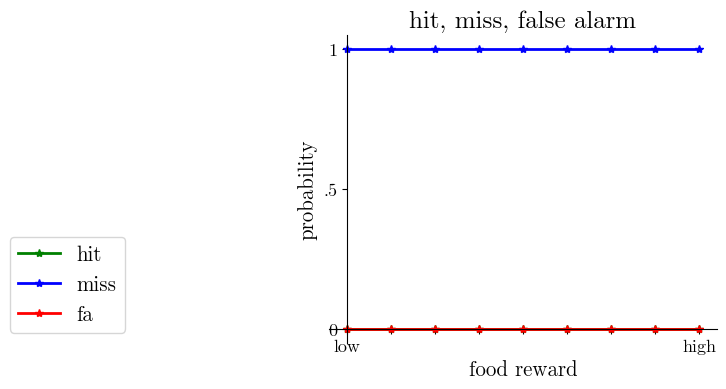

webf NOT subset; don't know how to subset; dropped


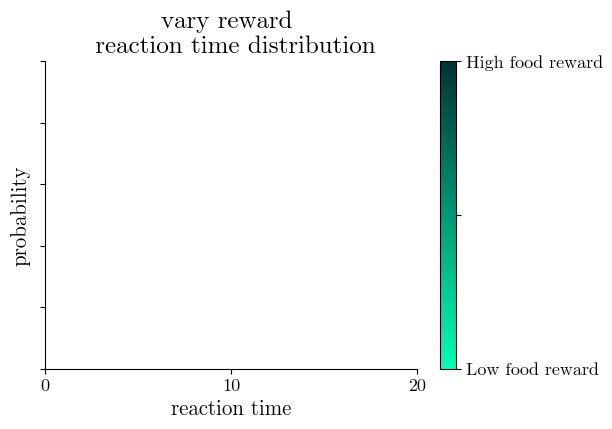

ycstore/seed_0_varyrewardemulate_epoch_1


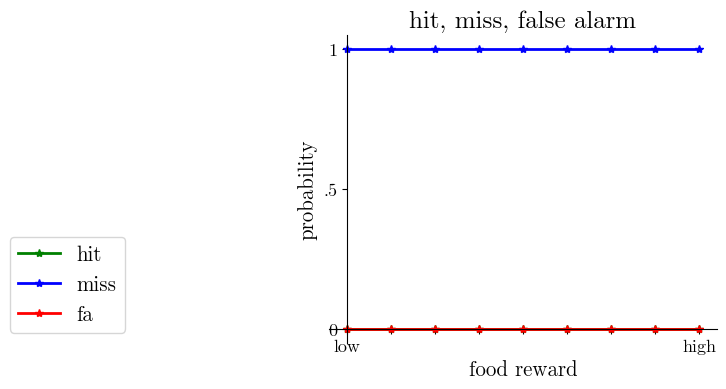

webf NOT subset; don't know how to subset; dropped


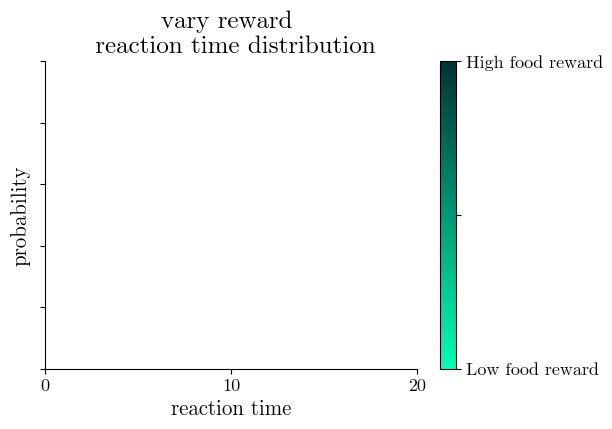

ycstore/seed_0_varyrewardemulate_epoch_2


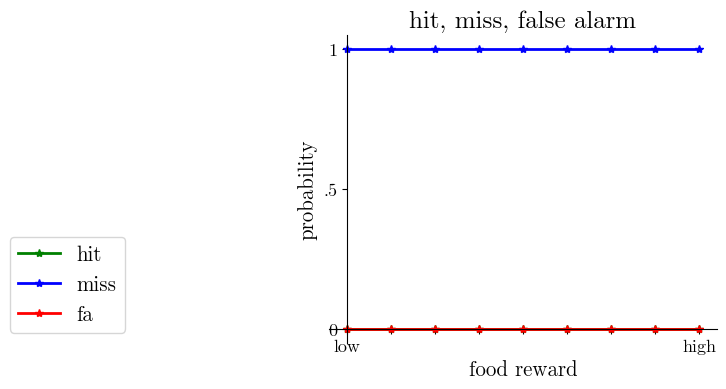

webf NOT subset; don't know how to subset; dropped


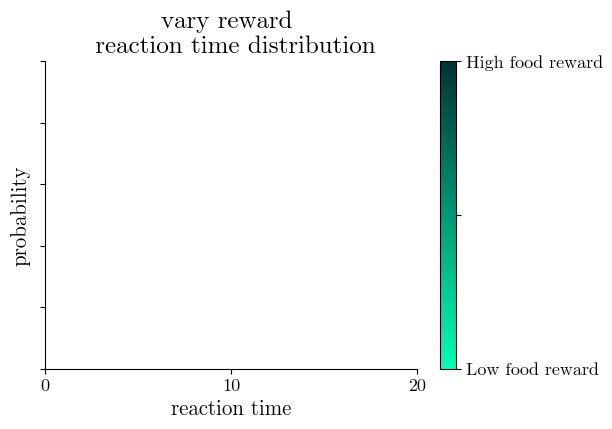

ycstore/seed_0_varyrewardemulate_epoch_3


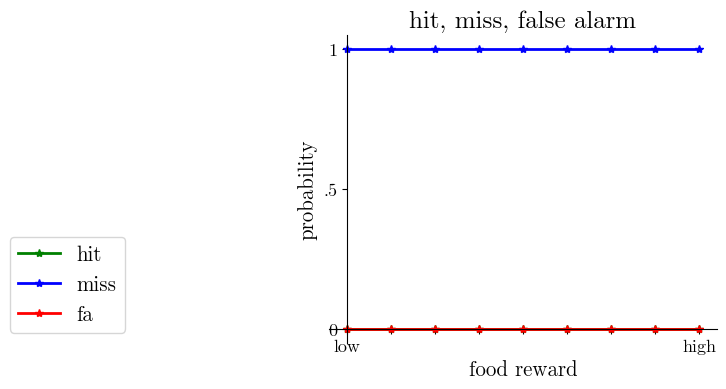

webf NOT subset; don't know how to subset; dropped


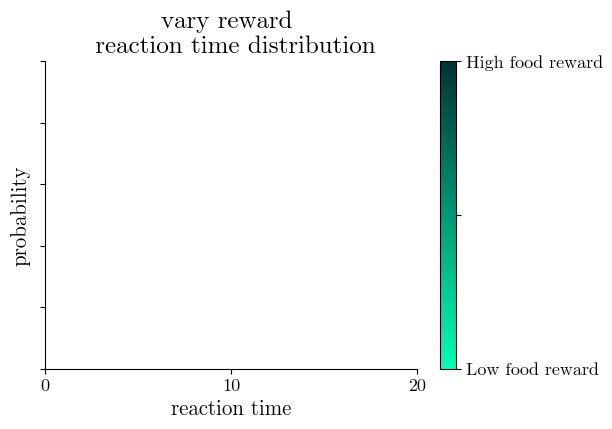

ycstore/seed_0_varyrewardemulate_epoch_4


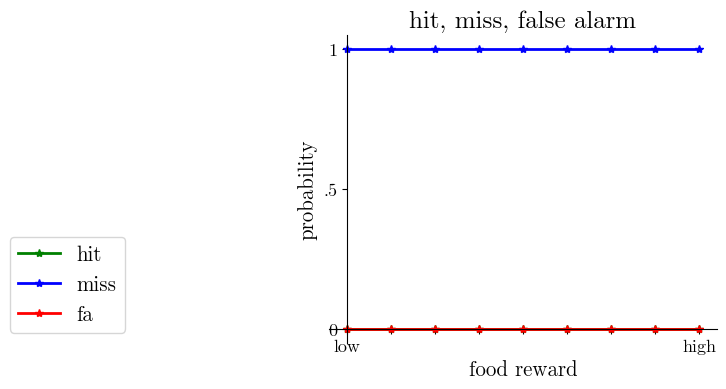

webf NOT subset; don't know how to subset; dropped


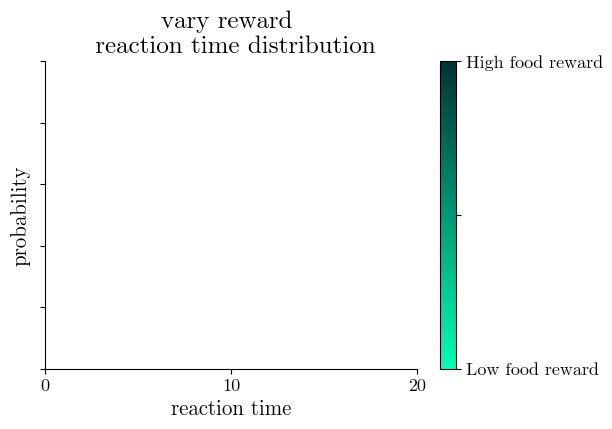

ycstore/seed_0_varyrewardemulate_epoch_5


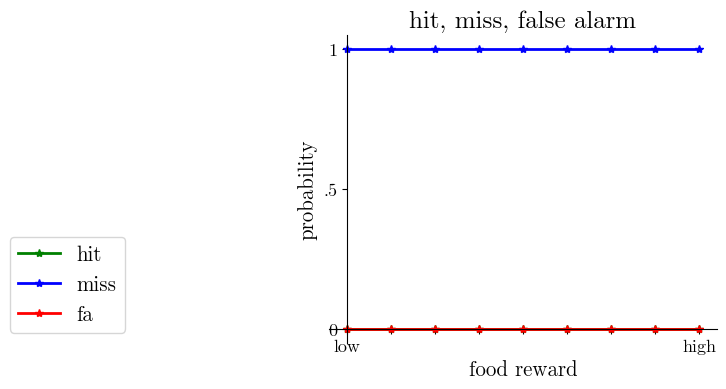

webf NOT subset; don't know how to subset; dropped


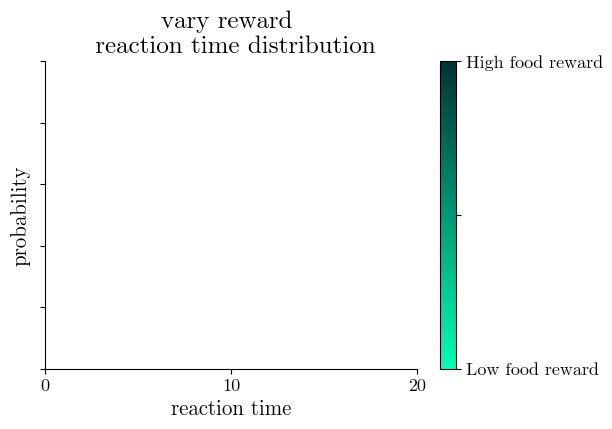

ycstore/seed_0_varyrewardemulate_epoch_6


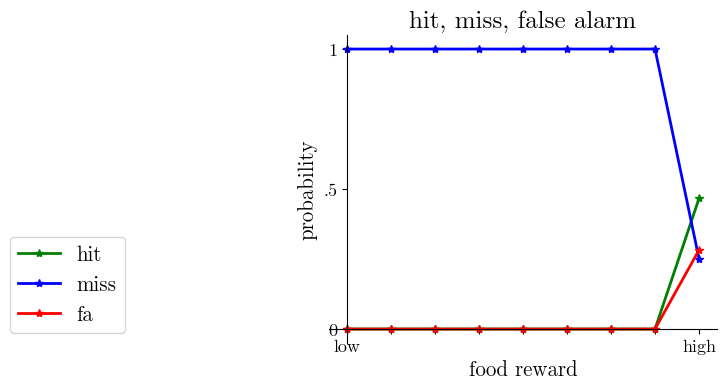

webf NOT subset; don't know how to subset; dropped


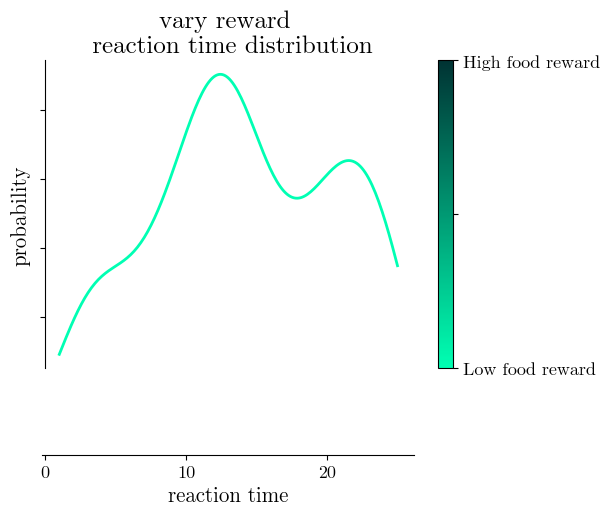

ycstore/seed_0_varyrewardemulate_epoch_7


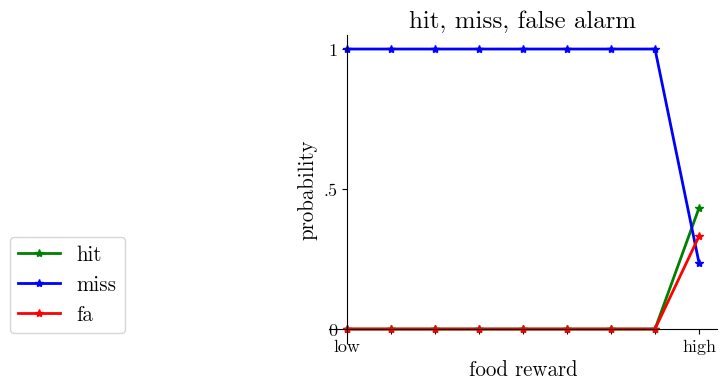

webf NOT subset; don't know how to subset; dropped


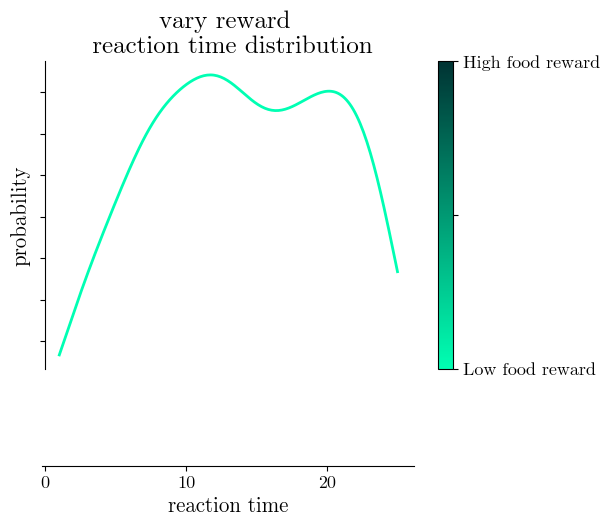

ycstore/seed_0_varyrewardemulate_epoch_8


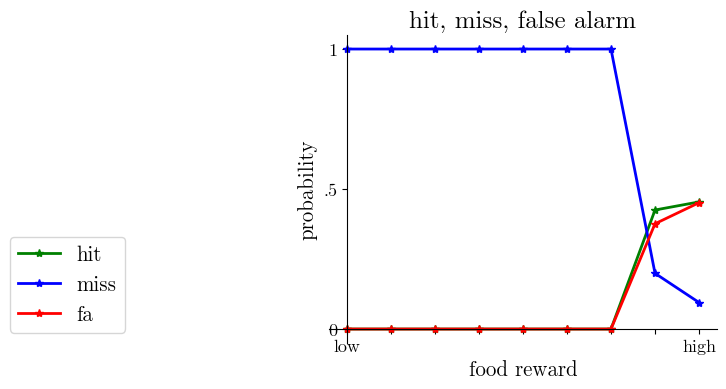

webf NOT subset; don't know how to subset; dropped


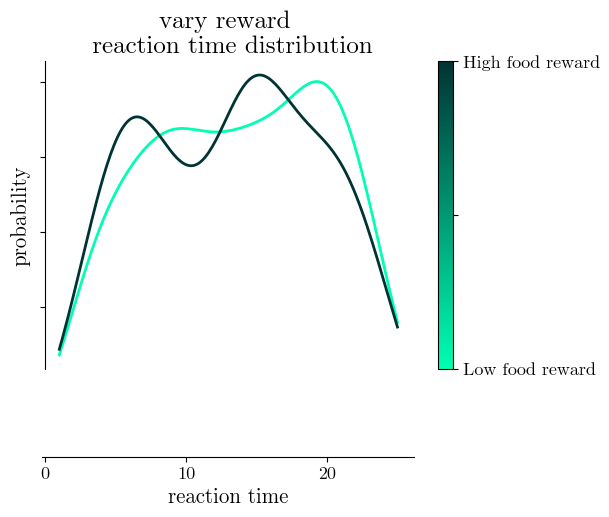

ycstore/seed_0_varyrewardemulate_epoch_9


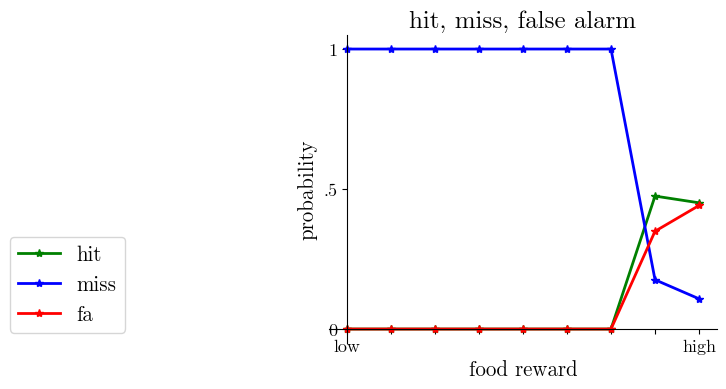

webf NOT subset; don't know how to subset; dropped


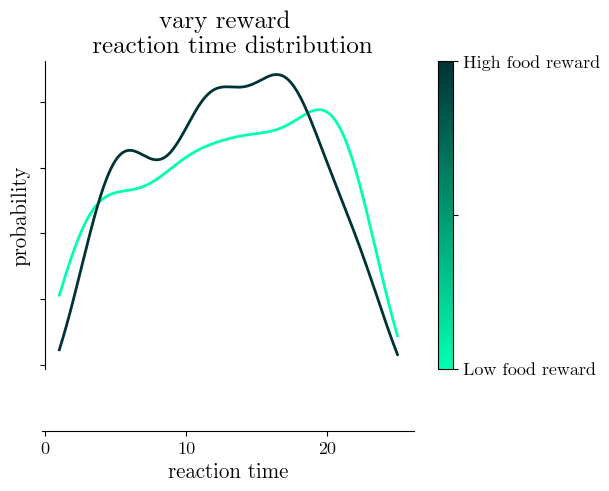

ycstore/seed_0_varyrewardemulate_epoch_10


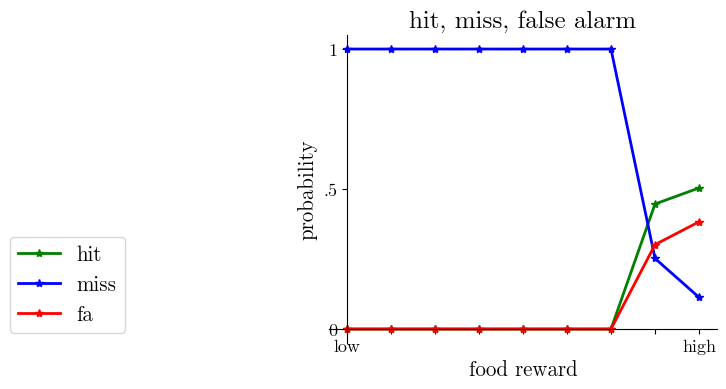

webf NOT subset; don't know how to subset; dropped


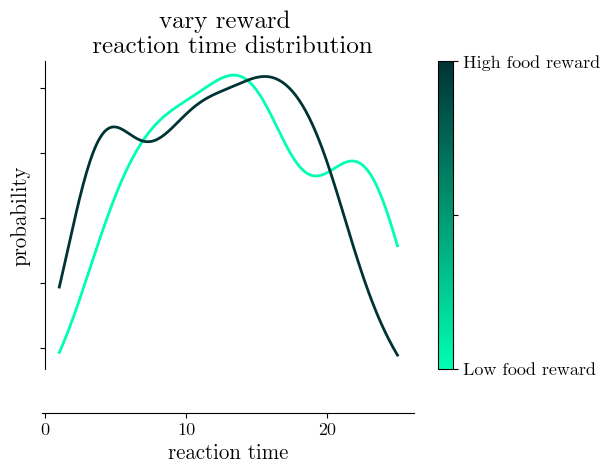

In [3]:
modelname = 'varyrewardemulate'
# training hyper params
epoch_size = 33333
n_epoch = 22
n_seed = 1
modeli = 0
attcost=-1.6
facost=-50
p1p2 = np.array([.5, .6])
vmin, vmax = 10, 5000
food_reward_list = np.linspace(vmin, vmax, 9)
print('food reard list: ', [f'{a:.0f}' for a in food_reward_list])
env_param = [0, None, attcost, .25, facost, 0, 0]
seed=0
thismodel = f'seed_{seed}_{modelname}'

for seed in range(n_seed):
    # set seed
    np.random.seed(seed)
    task = AFR2(spec={'agent': {'lick_cost': env_param[0],
                                'food_reward': env_param[1],
                                'attention_cost_coeff': env_param[2],
                                'attention_cost_temp': env_param[3],
                                'penalty_cost': env_param[4],
                                'iti_cost': env_param[5],
                                'time_in_game_reward': env_param[6]}})
    task.food_reward_list = food_reward_list
    taskbelief = FuncBeliefModel(env=task, rng=1)
    # set p1 p2
    task.obs_certainity_possible = p1p2
    model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu',
                clip_range=0.1, ent_coef=0.01, tensorboard_log=f"runs/{modelname}",)
    # train
    for i in range(n_epoch):
        model.learn(total_timesteps=epoch_size,
                    tb_log_name=thismodel,
                    reset_num_timesteps=False,
                    )
        model.save(f'ycstore/{thismodel}_epoch_{i}')
        print(f'ycstore/{thismodel}_epoch_{i}')

        # eval
        # collect trial data
        no_episodes=3333
        def eval_wrapper(a):
            episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                    num_steps=100000, deterministic=True)
            return episode

        with multiprocess.Pool(processes=8) as pool:
            all_episode_data = pool.map(eval_wrapper, range(no_episodes))

        # process trial data
        def process_one_episode_wrapper(episode):
            return process_one_episode(episode, task)
        with multiprocess.Pool(processes=8) as pool:
            results = pool.map(process_one_episode_wrapper, all_episode_data)

        # process the mp results
        hit_count_list = [[0] for _ in range(len(food_reward_list))]
        miss_count_list = [[0] for _ in range(len(food_reward_list))]
        false_alarm_list = [[0] for _ in range(len(food_reward_list))]

        noise_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
        signal_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
        total_noise_time_list = [[0] for _ in range(len(food_reward_list))]
        total_signal_time_list = [[0] for _ in range(len(food_reward_list))]

        # dist naming space: list of list of num. big list of each reward cond. small list of each trial's summary stats, which is a single number.
        total_reward_dist= [[] for _ in range(len(food_reward_list))]
        rt_hit_dist=[[] for _ in range(len(food_reward_list))]
        rt_fa_dist=[[] for _ in range(len(food_reward_list))]
        total_att_time_dist = [[] for _ in range(len(food_reward_list))]
        for res in results:
            (food_reward_idx,
            hit_count,
            miss_count,
            false_alarm_count,

            noise_time_before_lick,
            signal_time_before_lick,
            total_noise_time,
            total_signal_time,

            total_reward,

            attention_time_points_across_episodes,
            episode_length_across_episodes,
            hit_reaction_time_across_episodes,
            fa_reaction_time_across_episodes
            ) = res

            hit_count_list[food_reward_idx][0] += (hit_count)
            miss_count_list[food_reward_idx][0] += (miss_count)
            false_alarm_list[food_reward_idx][0] += (false_alarm_count)

            noise_time_before_lick_list[food_reward_idx][0] += (noise_time_before_lick)
            signal_time_before_lick_list[food_reward_idx][0] += (
                signal_time_before_lick)
            total_noise_time_list[food_reward_idx][0] += (total_noise_time)
            total_signal_time_list[food_reward_idx][0] += (total_signal_time)

            total_reward_dist[food_reward_idx].append(total_reward)
            rt_hit_dist[food_reward_idx].append(signal_time_before_lick)
            rt_fa_dist[food_reward_idx].append(noise_time_before_lick)
            total_att_time_dist[food_reward_idx].append(len(attention_time_points_across_episodes[0]))


        # 3 curve
        hit_count_list, miss_count_list, false_alarm_list = np.array(
            hit_count_list), np.array(miss_count_list), np.array(false_alarm_list)
        hit_prob = [hit_count_list[i]/(hit_count_list[i]+miss_count_list[i] +
                                        false_alarm_list[i]) for i in range(len(hit_count_list))]
        miss_prob = [miss_count_list[i]/(hit_count_list[i]+miss_count_list[i] +
                                            false_alarm_list[i]) for i in range(len(hit_count_list))]
        fa_prob = [false_alarm_list[i]/(hit_count_list[i]+miss_count_list[i] +
                                        false_alarm_list[i]) for i in range(len(hit_count_list))]

        xs=np.arange(len(food_reward_list))
        fig, ax=plt.subplots(1,1, figsize=(5,4))

        ax.plot(xs, hit_prob, '-*g', label='hit')
        ax.plot(xs, miss_prob, '-*b', label='miss')
        ax.plot(xs, fa_prob, '-*r', label='fa')
        quickleg(ax, bbox_to_anchor=(-0.5,0))
        ax.set_xlabel('food reward')
        ax.set_ylabel('probability')
        # ax.set_xticks(xs, [f'{a:.0f}' for a in food_reward_list]) # actual values
        ax.set_xticks([xs[i] for i in [0,-1]], ['low', 'high']) # low high
        ax.set_xticks(xs)
        ax.set_yticks([0,0.5,1], ['0', '.5','1'])
        ax.set_xticks(xs)
        centerax(ax)
        ax.set_title('hit, miss, false alarm')
        plt.show()

        # reaction time

        start_rgb = (0.0, 1, 0.7)
        end_rgb = (0.0, 0.2, 0.2)
        cmap = LinearSegmentedColormap.from_list('custom_cmap', [start_rgb, end_rgb])


        fig, ax = plt.subplots(1, 1, figsize=(6, 4))
        data = []
        for food_reward_idx, v in enumerate(rt_hit_dist):
            v = np.array(v)
            v = v[v > 1]  # ignore the 0 reaction time in the plots
            if len(v) == 0:
                continue
            data.append((food_reward_idx, v))


        for i, (food_reward_idx, curve) in enumerate(data):
            sns.kdeplot(curve, label=f'reward:{food_reward_list[food_reward_idx]:.0f}', clip=(1, np.max(v)), bw_adjust=1,color=cmap(np.linspace(0, 1, len(data)))[i])

            # plt.plot(curve, color=cmap(np.linspace(0, 1, len(data)))[i])
        color_bar=plt.colorbar(plt.cm.ScalarMappable(cmap=cmap),ax=ax)
        ticks = [0, 0.5, 1]
        tick_labels = ['Low food reward', '', 'High food reward']
        color_bar.set_ticks(ticks)
        color_bar.set_ticklabels(tick_labels)

        ax.set_ylabel('probability')
        ax.set_xlabel('reaction time')
        centerax(ax)
        ax.set_xticks([0, 10, 20])
        ax.set_yticklabels([])
        # quickleg(ax, bbox_to_anchor=(-0.5, 0))
        ax.set_title('vary reward \n reaction time distribution')
        quicksave('reaction time distribution v3 full', modelname)
        plt.show()

    notify(f'training {thismodel} finished')
modeli += 1

# eval

ycstore/seed_0_varyrewardperoid2_0_epoch_8


/Users/yc/repo/auditory-foraging-IRC/ult.py:572: RuntimeWarning: invalid value encountered in divide
  
/Users/yc/repo/auditory-foraging-IRC/ult.py:572: RuntimeWarning: invalid value encountered in divide
  


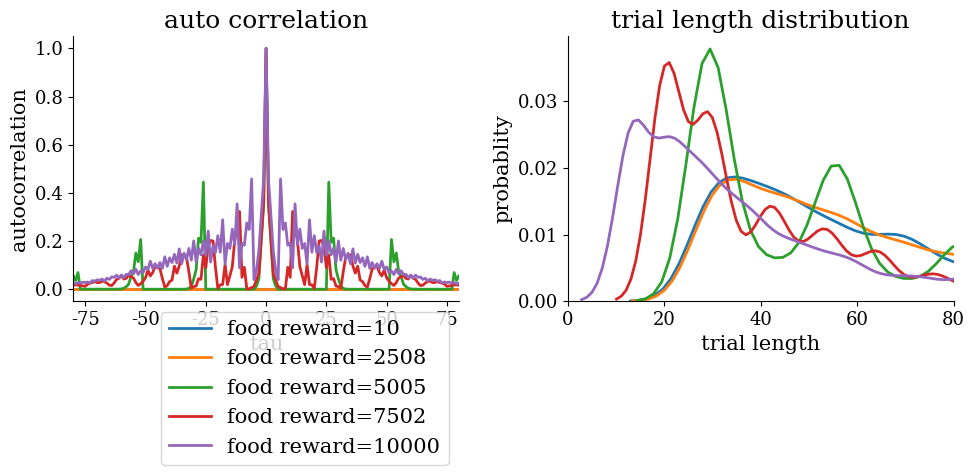

In [ ]:
modelname = 'varyrewardperoid2'
# training hyper params
epoch_size = 33333
n_epoch = 55
n_seed = 1
modeli = 0

no_episodes=6666
epochtouse=8

for attcost in [-1.6]:
    for facost in [-50,]:
        for p1p2 in [np.array([.5, .7])]:
            vmin, vmax = 10, 10000
            food_reward_list = np.linspace(vmin, vmax, 5)
            env_param = [0, None, attcost, .25, facost, 0, 0]
            seed=0
            thismodel = f'seed_{seed}_{modelname}_{modeli}'
            
            for seed in range(n_seed):
                np.random.seed(seed)
                task = AFR2(spec={'agent': {'lick_cost': env_param[0],
                                            'food_reward': env_param[1],
                                            'attention_cost_coeff': env_param[2],
                                            'attention_cost_temp': env_param[3],
                                            'penalty_cost': env_param[4],
                                            'iti_cost': env_param[5],
                                            'time_in_game_reward': env_param[6]}})
                task.food_reward_list = food_reward_list
                taskbelief = FuncBeliefModel(env=task, rng=1)
                # set p1 p2
                task.obs_certainity_possible = p1p2
                
              
                for i in range(epochtouse,epochtouse+1):
                    
                    
                    model = PPO.load(f'ycstore/{thismodel}_epoch_{i}')
                    print(f'ycstore/{thismodel}_epoch_{i}')

                    # collect trial data
                    import multiprocess
                
                    def eval_wrapper(a):
                        episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                                num_steps=100000, deterministic=True)
                        return episode

                    with multiprocess.Pool(processes=8) as pool:
                        all_episode_data = pool.map(eval_wrapper, range(no_episodes))

                    all_reward_res={} # k: v = foodreward idx: this food reward res
                    for r in range(len(food_reward_list)):
                        attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=[],[],[],[],[],[]
                        all_reward_res[r]=attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len

                    for episode in all_episode_data:
                        attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
                        att_time_list.append(
                            np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
                        if episode['actions'][-1][0] == 1:
                            lick_time_list.append(len(episode['states']))
                        else:
                            lick_time_list.append(None)
                        trial_len.append(len(episode['actions']))


                    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
                    # auto correlation    
                    for food_reward_idx in range(len(food_reward_list)):
                        att_seq_list = []
                        for episode in all_episode_data:
                            if episode['trial_food_reward_idx']==food_reward_idx:
                                att_seq_list.append([float(elt[1]) for elt in episode['actions']])
                        # Sorting based on increasing trial length
                        sorted_list_of_lists = sorted(att_seq_list, key=len)
                        sequences = sorted_list_of_lists[-333:-1] # Choosing what range of trial lengths to use. Could modify to be more consistent.
                        normalized_sequences = []
                        max_length = 0
                        for sequence in sequences:
                            normalized_seq = np.array(sequence)
                            if not np.isnan(normalized_seq.any()):
                                normalized_sequences.append(normalized_seq)
                                max_length = max(max_length, len(normalized_seq))    
                            
                        padded_sequences = []
                        for seq in normalized_sequences:
                            padded_seq = np.pad(seq, (0, max_length - len(seq)), mode='constant')
                            padded_sequences.append(padded_seq)

                        autocorrelation_sum = np.zeros(2 * max_length - 1)
                        for seq in padded_sequences:
                            autocorrelation_sum += np.nan_to_num(compute_autocorrelation(seq), nan=0)


                        average_autocorrelation = autocorrelation_sum / len(padded_sequences)
                        xs=np.arange(0,len(average_autocorrelation),1)
                        xs=xs-len(xs)//2
                        ax1.plot(xs,average_autocorrelation,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
                        ax1.set_xlabel('tau')
                        ax1.set_ylabel('autocorrelation')
                        ax1.set_xlim(-80,80)
                        # ax1.set_title(f'food reward={food_reward_list[food_reward_idx]:.0f} epoch:{i}')
                        ax1.set_title('auto correlation')
                        ax1.legend()

                        # ax2.hist([len(a) for a in att_seq_list])
                        sns.kdeplot([len(a) for a in att_seq_list], fill=False, bw_adjust=0.5)
                        ax2.set_xlabel('trial length')
                        ax2.set_ylabel('probablity')
                        ax2.set_xlim(0,80)
                        ax2.set_title('trial length distribution')
                        # ax2.set_title(f'food reward={food_reward_list[food_reward_idx]:.0f} epoch:{i}')

                    ax1.legend(bbox_to_anchor=(1,0))
                    plt.tight_layout()
                    quicksave('autocorr', modelname)
                    plt.show()


                    # # heatmap trial indicator (att and lick)
                    # for food_reward_idx in (all_reward_res.keys()):
                    #     attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[food_reward_idx]
                    #     sortind=np.argsort(trial_len[:plot_no_episodes])

                    #     grid = np.zeros((plot_no_episodes, max(trial_len)+2))

                    #     # att
                    #     plot_data =att_time_list[:plot_no_episodes]
                    #     for i, arr in enumerate(plot_data):
                    #         grid[i, arr] = -1

                    #     # lick
                    #     plot_data =lick_time_list[:plot_no_episodes]
                    #     for i, arr in enumerate(plot_data):
                    #         if arr:
                    #             grid[i, arr] = 1
                        
                    #     plt.figure()
                    #     c=plt.imshow(grid[sortind], cmap='bwr', vmin=-1, vmax=1,
                    #                     aspect='auto', interpolation='none')
                    #     # plt.colorbar(c)
                    #     plt.xlabel('time in trial')
                    #     plt.ylabel('episode no.')
                    #     plt.title(f'attn, food reward: {food_reward_list[food_reward_idx]}')

                    #     # legend
                    #     from matplotlib.patches import Patch

                    #     # Create Patch objects for the custom legend
                    #     red_patch = Patch(color='red', label='lick')
                    #     blue_patch = Patch(color='blue', label='attention')

                    #     # Create a new legend
                    #     extra_legend = plt.legend(handles=[red_patch, blue_patch], loc='upper right', frameon=True)
                    #     frame = extra_legend.get_frame()
                    #     frame.set_color('lightgrey')

                    #     # Add the new legend to the existing plot
                    #     plt.gca().add_artist(extra_legend)
                    #     quicksave(f'ep indicator {food_reward_idx}', modelname)
                    #     plt.show()

   

/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/histograms.py:883: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


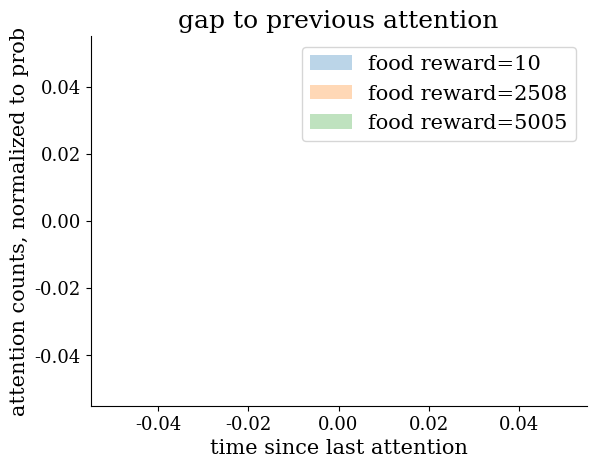

ValueError: zero-size array to reduction operation maximum which has no identity

In [ ]:
att_time_list
# figure 7
# for food_reward_idx, v in all_reward_res.items():
#     attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=v
#     att_size_previous=[previous_block_size(a) for a in att_time_list]
#     a=np.concatenate(att_size_previous)
#     plt.hist(a, bins=np.linspace(2,15,15), alpha=0.3, density=True,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
#     # sns.kdeplot(a, fill=False, bw_adjust=0.5)
# plt.ylim(0,1)
# plt.title('previous attention block size')
# plt.ylabel('attention counts, normalized to prob')
# plt.xlabel('previous attention block size')
# plt.legend()
# plt.show()

for food_reward_idx, v in all_reward_res.items():
    if food_reward_idx in [0,1,2]:
        attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=v
        att_gap2previous=[previous_item_gap(a) for a in att_time_list]
        a=np.concatenate(att_gap2previous)
        plt.hist(a, bins=np.linspace(2,15,15), alpha=0.3, density=True,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
        # sns.kdeplot(a, fill=False, bw_adjust=0.5)
# plt.ylim(0,1)
plt.title('gap to previous attention')
plt.ylabel('attention counts, normalized to prob')
plt.xlabel('time since last attention')
plt.legend()
plt.show()

for food_reward_idx, v in all_reward_res.items():
    # if food_reward_idx in [3,4]:
        attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=v
        att_gap2previous=[previous_item_gap(a) for a in att_time_list]
        a=np.concatenate(att_gap2previous)
        a=a[a>0]
        # plt.hist(a, bins=np.linspace(2,15,15), alpha=0.3, density=False,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
        sns.kdeplot(a, fill=False,clip=(0, np.max(a)), bw_adjust=3,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
# plt.ylim(0,1)
plt.title('gap to previous attention')
plt.ylabel('attention counts, normalized to prob')
plt.xlabel('time since last attention')
plt.legend()
quicksave('gap full', modelname)
plt.show()

for food_reward_idx, v in all_reward_res.items():
    if food_reward_idx in [0,2,4]:
        attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=v
        att_gap2previous=[previous_item_gap(a) for a in att_time_list]
        a=np.concatenate(att_gap2previous)
        a=a[a>0]
        # plt.hist(a, bins=np.linspace(2,15,15), alpha=0.3, density=False,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
        sns.kdeplot(a, fill=False, clip=(0, np.max(a)),bw_adjust=3,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
plt.xlim(0,15)
plt.title('gap to previous attention')
plt.ylabel('attention counts, normalized to prob')
plt.xlabel('time since last attention')
plt.legend()
quicksave('gap', modelname)
plt.show()

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_81565/2049812381.py:18: RuntimeWarning: invalid value encountered in divide
  counts_normalized = counts / np.sum(counts)


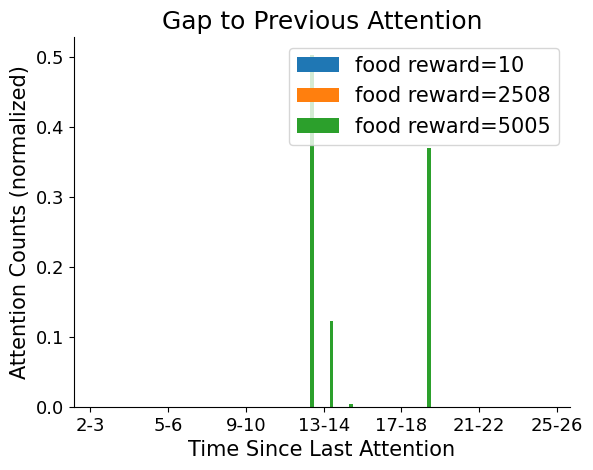

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Initialize lists for each reward
reward_labels = []
reward_data = []

for food_reward_idx, v in all_reward_res.items():
    if food_reward_idx in [0, 1, 2]:
        attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = v
        att_gap2previous = [previous_item_gap(a) for a in att_time_list]
        a = np.concatenate(att_gap2previous)
        
        # Count occurrences of values within bins
        counts, bins = np.histogram(a, bins=np.linspace(2, 25, 25))
        
        # Normalize counts
        counts_normalized = counts / np.sum(counts)
        
        reward_labels.append(f'food reward={food_reward_list[food_reward_idx]:.0f}')
        reward_data.append(counts_normalized)

# Create side-by-side bar chart
fig, ax = plt.subplots()
width = 0.2  # Width of each bar
x = np.arange(len(bins) - 1)

for i in range(len(reward_labels)):
    ax.bar(x + i * width, reward_data[i], width=width, label=reward_labels[i])

# Add labels and legend
ax.set_title('Gap to Previous Attention')
ax.set_ylabel('Attention Counts (normalized)')
ax.set_xlabel('Time Since Last Attention')

# Reduce number of xticks
num_xticks = 6
plt.xticks(np.arange(0, len(bins), step=int(len(bins) / num_xticks)), [f'{int(bin)}-{int(bin+1)}' for bin in bins[::int(len(bins) / num_xticks)]])
    
ax.legend()

plt.show()


In [ ]:
notify()